In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "data" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('data/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

data/sample_submission.csv
data/test.csv
data/train.csv


# Credit Loan Payback Prediction
[Kaggle Playground Series S5E11](https://www.kaggle.com/competitions/playground-series-s5e11)

**Goal:** Predict the probability that a borrower will successfully pay back their loan.

**Author:** [Ejtolf](https://www.kaggle.com/arraylist1402)

**Best Kaggle Score:** ROC-AUC = 0.9221

In [3]:
import warnings
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
# Default env settings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (6, 5)
%matplotlib inline

In [4]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print('--- TRAIN DATA ---')
display(train_df.head())
print('--- TEST DATA ---')
display(test_df.head())

--- TRAIN DATA ---


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


--- TEST DATA ---


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


In [5]:
df = train_df.copy()

# General info
print('-' * 15)
display(df.info())
print('-' * 15)
display(f'Size: {df.shape[0]} returns, {df.shape[1]} features.')
print('-' * 15)
if not df.isna().any().any() and not df.duplicated().sum(): # No msn values & duplicates
    print('No missing values')
    print('No duplicates.')
else:
    print(f'Missing values:')
    display(df.isna().sum())
    display(msno.matrix(df))
    print(f'Duplicates: {df.duplicated().sum()}')

---------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


None

---------------


'Size: 593994 returns, 13 features.'

---------------
No missing values
No duplicates.


In [6]:
# One client info
df.head(1)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0


In [7]:
df.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

## Features overview

There are 593994 clients in train dataset with 13 features:

- **id** – Unique identifier for each record (loan or borrower).  
- **annual_income** – Borrower’s annual income, indicator of repayment ability.  
- **debt_to_income_ratio** – Ratio of total debt to annual income; higher values indicate higher credit risk.  
- **credit_score** – Creditworthiness score, typically from 300 to 850; higher is better.  
- **loan_amount** – The total amount of money borrowed.  
- **interest_rate** – Interest rate applied to the loan; often higher for riskier borrowers.  
- **gender** – Borrower’s gender (e.g., Male, Female, Other).  
- **marital_status** – Marital status of the borrower (Single, Married, Divorced, etc.).  
- **education_level** – Highest education level attained by the borrower (High School, Bachelor, Master, etc.).  
- **employment_status** – Employment condition (Employed, Unemployed, Self-Employed, Retired, etc.).  
- **loan_purpose** – Purpose of the loan (Debt Consolidation, Car, Education, Home Improvement, etc.).  
- **grade_subgrade** – Credit grade assigned by the lender (e.g., A1, B2), reflecting internal risk evaluation.  
- **loan_paid_back** – Target variable: 1 if the loan was repaid, 0 otherwise.  


# 1. Exploratory data analysis.

## 1.1. Previous data visualisation

In [8]:
df = df.drop(columns=['id'])

num_features = df.select_dtypes(include=['int64', 'float64'])
cat_features = pd.concat([df.select_dtypes(exclude=['int64', 'float64']), df['loan_paid_back']], axis=1)
target = 'loan_paid_back'
# cat_features.head()

print(f'Numeric features: {num_features.columns}\n')
print(f'Categorial features: {cat_features.columns}')

Numeric features: Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'loan_paid_back'],
      dtype='object')

Categorial features: Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade', 'loan_paid_back'],
      dtype='object')


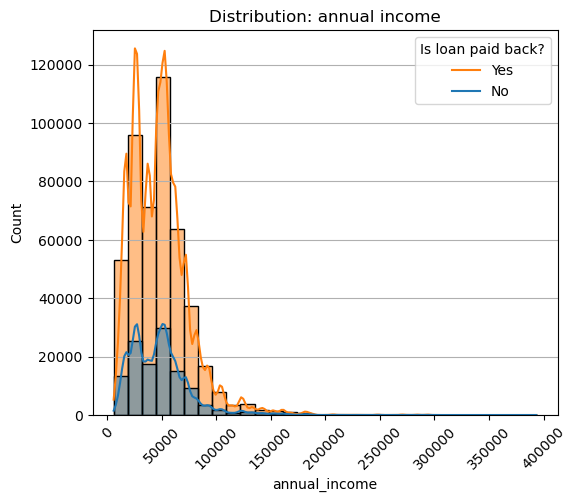

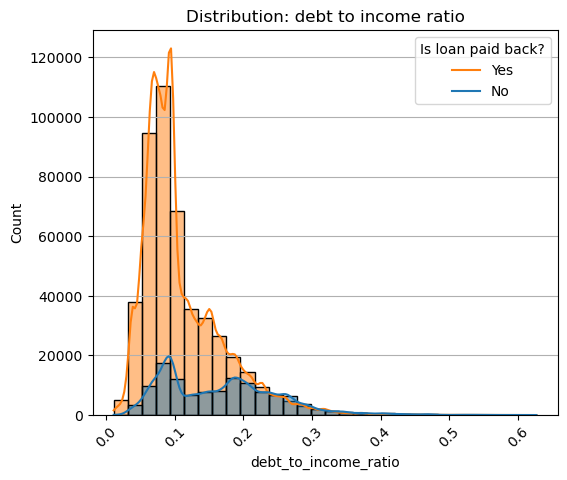

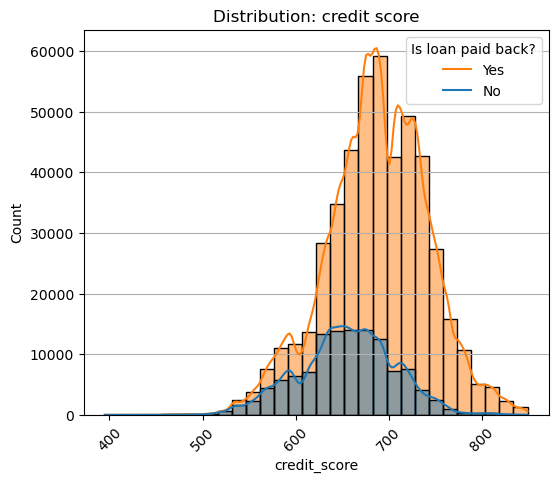

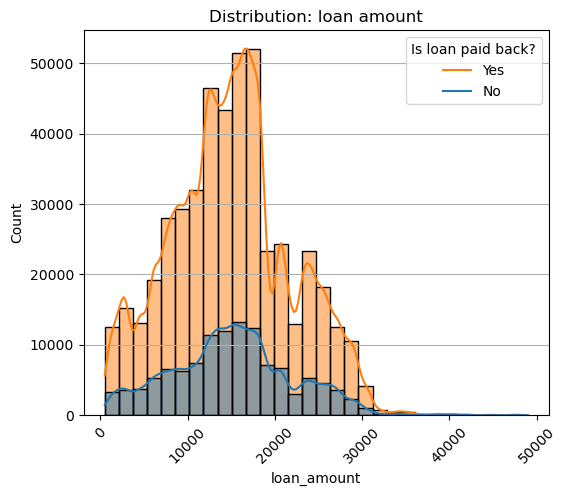

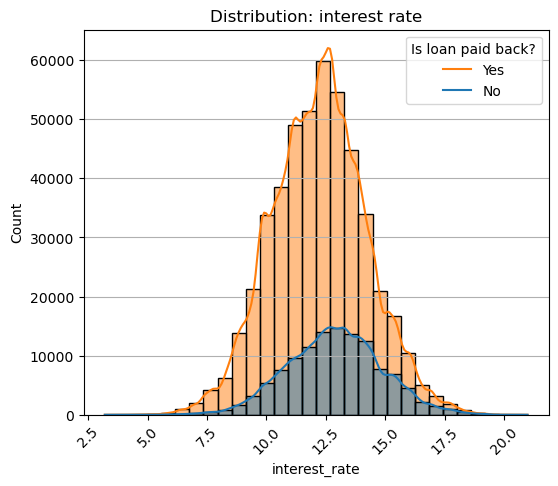

In [9]:
for feature in num_features.drop(columns=['loan_paid_back']):
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        hue=target,
        bins=30
    )
    plt.title(f'Distribution: {feature.replace("_", " ")}')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.legend(title='Is loan paid back?', labels=['Yes', 'No'])
    plt.show()

## Short Conclusion
- The visible majority earns up to 100,000–120,000 per year. There is a positive correlation between income level and loan repayment.  
- The higher the debt-to-income ratio, the greater the chance of default (starting from 0.2, almost no borrowers repaid their loans). There is likely a strong dependence between the debt-to-income ratio and default probability.  
- Credit scores start from around 500 points. The higher the credit score, the greater the likelihood of repayment.  
- The most common loan amount is around $30,000. Loan size affects repayment probability but is not a decisive factor.  
- The highest repayment probability is observed at an interest rate of 12.5%.  

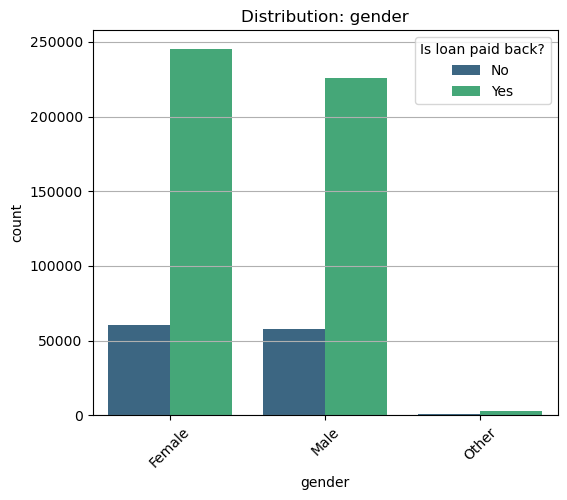

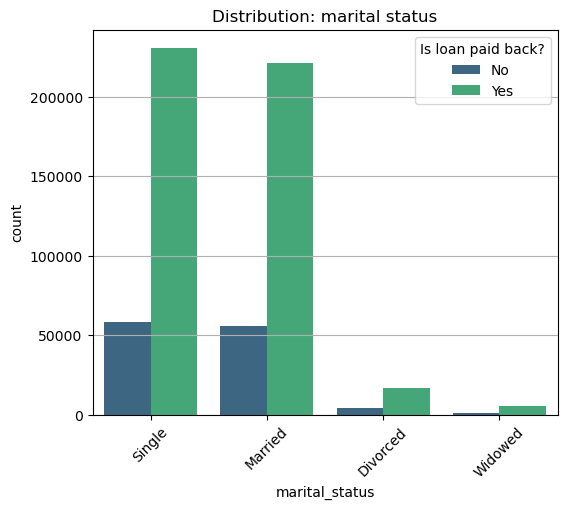

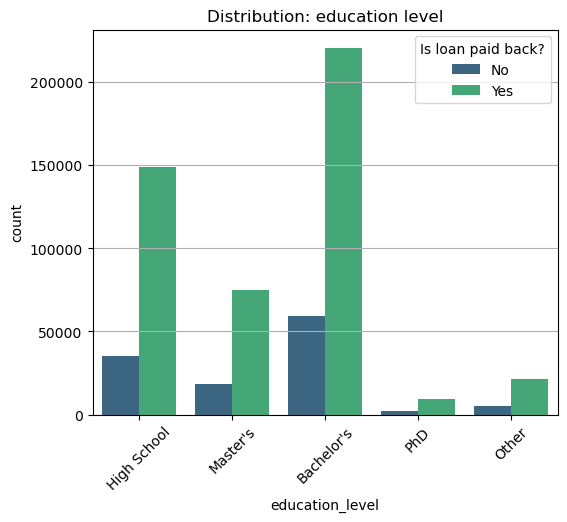

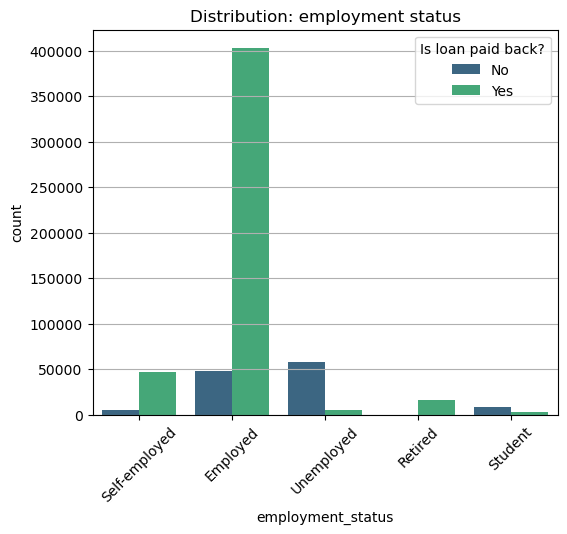

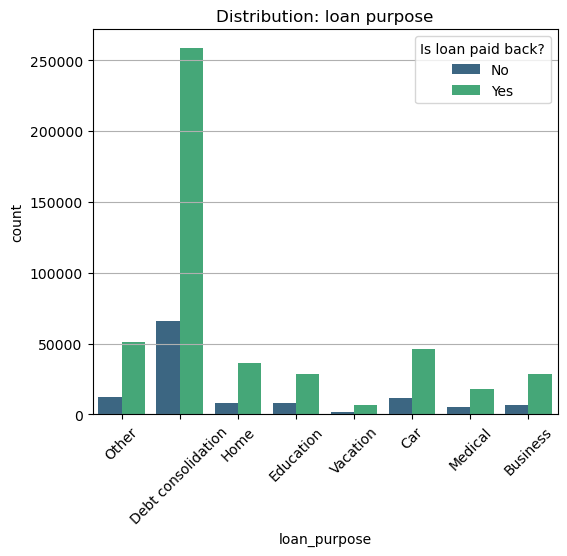

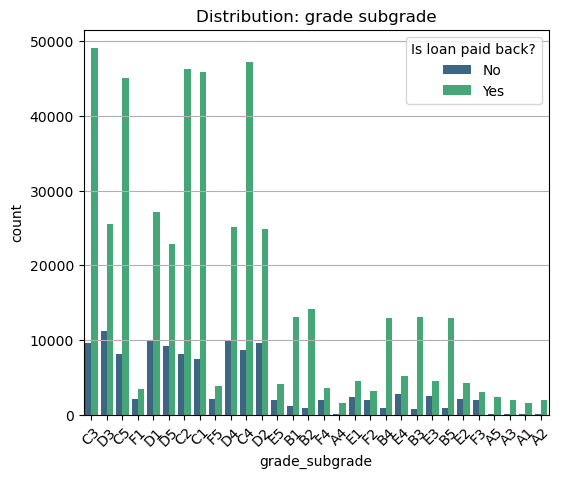

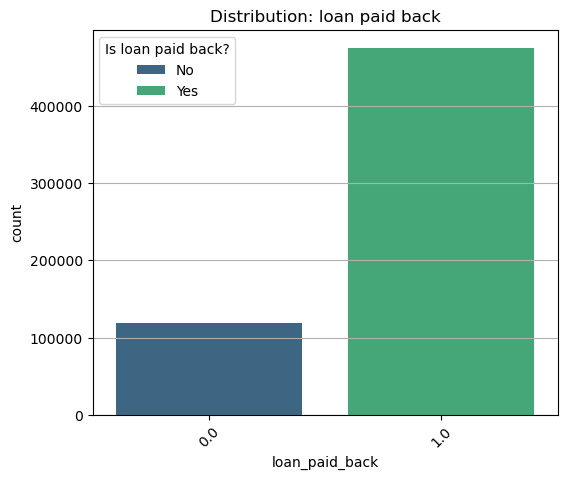

In [10]:
for feature in cat_features[:-1]:
    sns.countplot(
        data=df,
        x=feature,
        hue=target,
        palette='viridis'
    )
    plt.title(f'Distribution: {feature.replace("_", " ")}')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.legend(title='Is loan paid back?', labels=['No', 'Yes'])
    plt.show()

Feature correlation (sorted by absolute correlation)


,feature,correlation,Abs(correlation)
3,loan_amount,-0.003762,0.003762
0,annual_income,0.006326,0.006326
4,interest_rate,-0.131184,0.131184
2,credit_score,0.234560,0.234560
1,debt_to_income_ratio,-0.335680,0.335680
5,loan_paid_back,1.000000,1.000000


---------------------------------------------


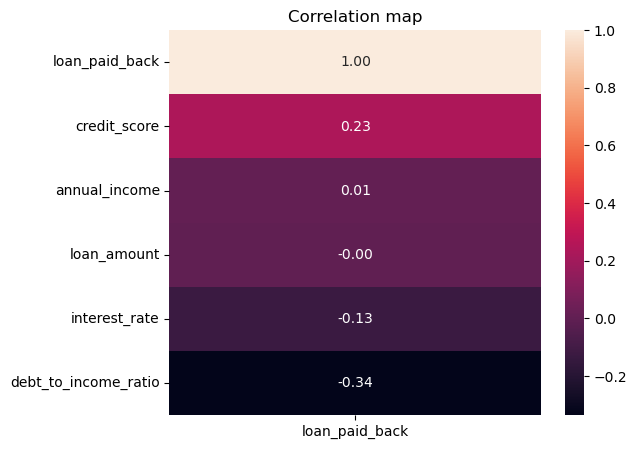

In [11]:
corr_mtx = df.corr(numeric_only=True)

# Correlation: feature scores dataframe
corr_with_target = corr_mtx['loan_paid_back']
corr_scoring_df = (
    corr_with_target
    .reset_index()
    .rename(columns={'index': 'feature', 'loan_paid_back': 'correlation'})
)
corr_scoring_df['Abs(correlation)'] = np.abs(corr_scoring_df['correlation'])

print('Feature correlation (sorted by absolute correlation)')
display(corr_scoring_df.sort_values(by='Abs(correlation)'))

print('-' * 45)

# Heatmap: feature correlation
sns.heatmap(corr_mtx[['loan_paid_back']].sort_values(by='loan_paid_back',ascending=False),
            annot=True, fmt='.2f', cmap='rocket')
plt.title('Correlation map')
plt.show()

## Feature Correlation Analysis

The correlation of each feature with the target (`loan_paid_back`) reveals the following insights:

- **Debt-to-Income Ratio** has the strongest negative correlation (-0.336) with loan repayment, indicating that borrowers with higher debt relative to their income are less likely to repay.  
- **Credit Score** shows a positive correlation (0.235), suggesting that higher credit scores increase the likelihood of repayment.  
- **Interest Rate** has a small negative correlation (-0.131), implying that higher interest rates slightly reduce repayment probability.  
- **Annual Income** and **Loan Amount** have very weak correlations (0.006 and -0.004, respectively), indicating little direct linear influence on repayment in this dataset.  
- As expected, the target `loan_paid_back` correlates perfectly with itself (1.0).  

**Conclusion:** The most influential features for predicting loan repayment appear to be **debt-to-income ratio** and **credit score**, while other numerical features have minor linear effects.

## 1.2. Statistical tests

- For numerial - Student's t-test
- For categorial - Chi^2-test

In [12]:
from scipy.stats import ttest_ind, chi2_contingency

In [13]:
def ttest(feature):
    loan_paid_df = df[df['loan_paid_back'] == 1][feature]
    loan_default_df = df[df['loan_paid_back'] == 0][feature]

    t_stat, p_value = ttest_ind(loan_paid_df, loan_default_df, equal_var=False)
    print(f'{feature.replace("_", " ").upper()} is {"SIGNIFICANT" if p_value < .05 else "NOT SIGNIFICANT"}.')
    print(f'T-statistics: {t_stat:.2f} | P-value: {p_value:.5f}')

In [14]:
for feature in num_features:
    print('-' * 15)
    ttest(feature)

---------------
ANNUAL INCOME is SIGNIFICANT.
T-statistics: 4.81 | P-value: 0.00000
---------------
DEBT TO INCOME RATIO is SIGNIFICANT.
T-statistics: -224.67 | P-value: 0.00000
---------------
CREDIT SCORE is SIGNIFICANT.
T-statistics: 191.79 | P-value: 0.00000
---------------
LOAN AMOUNT is SIGNIFICANT.
T-statistics: -2.89 | P-value: 0.00381
---------------
INTEREST RATE is SIGNIFICANT.
T-statistics: -102.38 | P-value: 0.00000
---------------
LOAN PAID BACK is SIGNIFICANT.
T-statistics: inf | P-value: 0.00000


In [15]:
def chi2_test(feature):
    observed = pd.crosstab(index=df['loan_paid_back'], columns=df[feature])

    chi2, p_value, dof, expeceted = chi2_contingency(observed) 
    
    print(f'{feature.replace("_", " ").upper()} is {"SIGNIFICANT" if p_value < .05 else "NOT SIGNIFICANT"}.')
    print(f'P-value: {p_value:.5f}')

In [16]:
for feature in cat_features:
    print('-' * 15)
    chi2_test(feature)

---------------
GENDER is SIGNIFICANT.
P-value: 0.00000
---------------
MARITAL STATUS is NOT SIGNIFICANT.
P-value: 0.24856
---------------
EDUCATION LEVEL is SIGNIFICANT.
P-value: 0.00000
---------------
EMPLOYMENT STATUS is SIGNIFICANT.
P-value: 0.00000
---------------
LOAN PURPOSE is SIGNIFICANT.
P-value: 0.00000
---------------
GRADE SUBGRADE is SIGNIFICANT.
P-value: 0.00000
---------------
LOAN PAID BACK is SIGNIFICANT.
P-value: 0.00000


## Statistical Significance of Features

The results of the statistical tests indicate which features have a significant relationship with the target variable (`loan_paid_back`):

### Significant Numerical Features
- **Annual Income**: t-stat = 4.81, p-value < 0.001 → significant  
- **Debt-to-Income Ratio**: t-stat = -224.67, p-value < 0.001 → highly significant  
- **Credit Score**: t-stat = 191.79, p-value < 0.001 → highly significant  
- **Loan Amount**: t-stat = -2.89, p-value = 0.0038 → significant  
- **Interest Rate**: t-stat = -102.38, p-value < 0.001 → highly significant  

### Significant Categorical Features
- **Gender**: p-value < 0.001 → significant  
- **Education Level**: p-value < 0.001 → significant  
- **Employment Status**: p-value < 0.001 → significant  
- **Loan Purpose**: p-value < 0.001 → significant  
- **Grade/Subgrade**: p-value < 0.001 → significant  

### Not Significant Feature
- **Marital Status**: p-value = 0.2486 → not significant  

**Conclusion:** Most numerical and categorical features are statistically significant predictors of loan repayment, with **debt-to-income ratio** and **credit score** being particularly strong. Only **marital status** does not show a significant relationship with the target.

## 1.2. Statistically singnificant features
- Significant: annual income, debt to income, credit score, loan amount, interest rate, gender, education evel, employment status, loan purpose, grade subgrade.
- Not significant: marital status

---

# 2. Feature engineering & modeling (logistic regression)

## 2.1 Train data

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [18]:
def add_features(df):
    df = df.copy()

    df["loan_amount"] = np.log1p(df["loan_amount"])
    df["annual_income"] = np.log1p(df["annual_income"])

    df["income_to_debt_ratio"] = df["annual_income"] / (df["annual_income"] * df["debt_to_income_ratio"] + 1e-6)
    df["credit_score_scaled"] = (df["credit_score"] - df["credit_score"].mean()) / df["credit_score"].std()

    df["risk_index"] = df["interest_rate"] * (1 / (df["credit_score"] + 1e-6))

    df["income_credit_interaction"] = df["annual_income"] * df["credit_score"]
    df["loan_interest_interaction"] = df["loan_amount"] * df["interest_rate"]

    df["is_self_employed"] = (df["employment_status"] == "Self-employed").astype(int)
    # df["is_married"] = (df["marital_status"] == "Married").astype(int)
    df["is_debt_consolidation"] = (df["loan_purpose"].str.lower().str.contains("debt")).astype(int)

    edu_map = {
        "High School": 1,
        "Associate": 2,
        "Bachelor's": 3,
        "Master's": 4,
        "Doctorate": 5
    }
    df["education_rank"] = df["education_level"].map(edu_map).fillna(0)

    df["grade_letter"] = df["grade_subgrade"].str[0]
    df["grade_num_only"] = df["grade_subgrade"].str[1].astype(float)
    df["grade_value"] = df["grade_letter"].apply(lambda x: ord(x) - 64) + df["grade_num_only"] / 10
    df["is_high_grade"] = (df["grade_value"] <= 3).astype(int)

    df["debt_to_credit_ratio"] = df["debt_to_income_ratio"] / (df["credit_score"] + 1e-6)
    
    df["solvency_index"] = (
        df["annual_income"] / (df["loan_amount"] * (1 + df["interest_rate"] / 100))
    ) * df["credit_score"]

    df["interest_vs_grade_median"] = (
        df["interest_rate"] / df.groupby("grade_letter")["interest_rate"].transform("median")
    )

    return df

In [19]:
df = add_features(df)
df.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,...,is_self_employed,is_debt_consolidation,education_rank,grade_letter,grade_num_only,grade_value,is_high_grade,debt_to_credit_ratio,solvency_index,interest_vs_grade_median
0,10.287695,0.084,736,7.835745,13.67,Female,Single,High School,Self-employed,Other,...,1,0,1.0,C,3.0,3.3,0,0.000114,850.099397,1.142022
1,10.003741,0.166,636,8.432528,12.92,Male,Married,Master's,Employed,Debt consolidation,...,0,1,4.0,D,3.0,4.3,0,0.000261,668.176017,0.991558
2,10.811085,0.097,694,9.741330,9.76,Male,Single,High School,Employed,Debt consolidation,...,0,1,1.0,C,5.0,3.5,0,0.000140,701.724061,0.815372
3,10.754904,0.065,533,8.451797,16.10,Female,Single,High School,Employed,Debt consolidation,...,0,1,1.0,F,1.0,6.1,0,0.000122,584.187787,1.096730
4,10.146344,0.053,665,9.407996,10.21,Male,Married,High School,Employed,Other,...,0,0,1.0,D,1.0,4.1,0,0.000080,650.748341,0.783576


In [20]:
loan_not_paid_count, loan_paid_count = df['loan_paid_back'].value_counts()
scale_pos_weight = loan_paid_count / loan_not_paid_count

scale_pos_weight

0.25184723094496453

In [21]:
X = df.drop(columns=[target, 'marital_status'])
y = df[target]

In [22]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(exclude=['int64', 'float64']).columns

In [24]:
numeric_transformer = MinMaxScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [26]:
pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(C=1, penalty='l2', solver='saga', max_iter=10000, class_weight='balanced'))
])

In [27]:
pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'income_to_debt_ratio', 'credit_score_scaled',
       'risk_index', 'income_credit_interaction', 'loan_interest_interaction',
       'is_self_employed', 'is_debt_consolidation', 'education_rank',
       'grade_num_only', 'grade_value', 'is_high_grade',
       'debt_to_credit_ratio', 'solvency_index', 'interest_vs_grade_median'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'grade_letter'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(C=1, class_weight='balanced',
                                    max_iter=10000, solver='saga'))])

In [28]:
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
# print("Mean AUC:", scores.mean(), "+-", scores.std())

In [29]:
y_pred = pipe_lr.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("--> ROC-AUC Score:", roc_auc_score(y_val, y_pred))

Accuracy: 0.8576334817633146

Classification Report:
               precision    recall  f1-score   support

         0.0       0.62      0.78      0.69     23900
         1.0       0.94      0.88      0.91     94899

    accuracy                           0.86    118799
   macro avg       0.78      0.83      0.80    118799
weighted avg       0.87      0.86      0.86    118799


Confusion Matrix:
 [[18533  5367]
 [11546 83353]]
--> ROC-AUC Score: 0.8268865690328071


In [30]:
# param_grid = {
#     'classifier__max_iter': [1000, 5000, 10000],
#     'classifier__C': [0.1, 1, 10, 100],
#     'classifier__penalty': ['l1', 'l2'],
#     "classifier__solver": ['saga']
# }

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# grid_search_logreg = GridSearchCV(
#     model,
#     param_grid=param_grid,
#     cv=cv,
#     scoring="roc_auc",
#     n_jobs=-1,
#     verbose=2
# )

# grid_search_logreg.fit(X, y)

# print('-' * 45)
# print("Best parameters:", grid_search_logreg.best_params_)
# print("Best ROC-AUC:", grid_search_logreg.best_score_)
# print('-' * 45)

## Best hyper parameters for logistic regression: 

```python
LogisticRegression(C=1, penalty='l2', solver='saga', max_iter=10000, class_weight='balanced')
```

### Scores:
- **Accuracy**: 0.8573641192265928
- **ROC-AUC**: 0.8267

## 2.2 Test data

In [31]:
X_test_processed = add_features(test_df).copy()
test_predictions = pipe_lr.predict(X_test_processed)
test_probabilities = pipe_lr.predict_proba(X_test_processed)

# test_predictions[:10]
test_probabilities[0]

array([0.2125876, 0.7874124])

In [32]:
encoder = pipe_lr.named_steps['preprocessor'].named_transformers_['cat']
ohe_features = encoder.get_feature_names_out(cat_cols)

# Features
features = np.concatenate([num_cols, ohe_features])
# Coefficients
coefs = pipe_lr.named_steps['classifier'].coef_.flatten()

feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefs,
    'Abs_importance': np.abs(coefs)
}).sort_values('Abs_importance', ascending=False)

print('10 most significant features')

feature_importance.head(20)

10 most significant features


,Feature,Coefficient,Abs_importance
1,debt_to_income_ratio,-15.252229,15.252229
16,debt_to_credit_ratio,11.604720,11.604720
7,risk_index,5.478998,5.478998
2,credit_score,4.900292,4.900292
6,credit_score_scaled,4.900292,4.900292
28,employment_status_Retired,4.776012,4.776012
31,employment_status_Unemployed,-4.040329,4.040329
4,interest_rate,-3.832305,3.832305
30,employment_status_Student,-2.352663,2.352663
5,income_to_debt_ratio,2.046375,2.046375


# 3. Gradient Boosting 

In [33]:
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

In [34]:
# LightGBM pipeline
pipe_lgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", lgb.LGBMClassifier(
        boosting_type='gbdt',
        objective='binary',
        metric='auc',
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=8,
        lambda_l1=0.5,
        lambda_l2=1.0,
        min_child_samples=50,
        scale_pos_weight=scale_pos_weight,
        is_unbalance=False,
        random_state=42,
        verbose=-1
    ))
])

# XGBoost pipeline
pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=500, 
        learning_rate=.05, 
        max_depth=6,
        tree_method='hist',
        random_state=42
    ))
])

In [49]:
def kolmagorov_smirnov_statistic(y_true, y_proba):
    y_val_ks = 1 - y_true
    y_pred_proba_ks = 1 - y_proba

    fpr, tpr, _ = roc_curve(y_val_ks, y_pred_proba_ks)
    ks = np.max(tpr - fpr)
    
    return ks

In [50]:
lgb_model = pipe_lgb.fit(X_train, y_train)
display(lgb_model)

y_pred = lgb_model.predict(X_val)
y_pred_proba = lgb_model.predict_proba(X_val)[:, 1]

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("--> ROC-AUC Score:", roc_auc_score(y_val, y_pred_proba))
print("--> Kolmogorov-Smirnov Statistic:", kolmagorov_smirnov_statistic(y_val, y_pred_proba))
print('-' * 100)
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'income_to_debt_ratio', 'credit_score_scaled',
       'risk_index', 'income_credit_interaction', 'loan_interest_interaction',
       'is_self_employed', 'is_debt_consolidation', 'education_rank'...
                                                  Index(['gender', 'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'grade_letter'],
      dtype='object'))])),
                ('classifier',
                 LGBMClassifier(is_unbalance=False, lambda_l1=0.5,
                                lambda_l2=1.0, learning_rate=0.03, max_depth=8,
                                metric='auc', min_child_samples=50,
                                n_estimators=2000, objective='binary',
                                random_state=42,
                                scale_pos_weight=0.25184723094496453,
                                verbose=-1))])

Accuracy: 0.8714130590324835
Recall: 0.8924646202805088
--> ROC-AUC Score: 0.9221496820601298
--> Kolmogorov-Smirnov Statistic: 0.682030622206097
----------------------------------------------------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

         0.0       0.65      0.79      0.71     23900
         1.0       0.94      0.89      0.92     94899

    accuracy                           0.87    118799
   macro avg       0.80      0.84      0.81    118799
weighted avg       0.88      0.87      0.88    118799


Confusion Matrix:
 [[18829  5071]
 [10205 84694]]


---

## LightGBM Model Performance <span style='color: green'>(BEST)</span>

**Accuracy:** 0.8714  

**Recall:** 0.8925

**KOLMAGOROV-SMIRNOV STATISTIC:** 0.6820

### Classification Report
| Class | Precision | Recall | F1-score | Support |
|-------|-----------|--------|----------|---------|
| 0.0   | 0.65      | 0.79   | 0.71     | 23,900  |
| 1.0   | 0.94      | 0.89   | 0.92     | 94,899  |
| **Accuracy** | - | - | 0.87 | 118,799 |
| **Macro Avg** | 0.80 | 0.84 | 0.81 | 118,799 |
| **Weighted Avg** | 0.88 | 0.87 | 0.88 | 118,799 |

### Confusion Matrix

```
[[18829 5071]
[10205 84694]]
```

**ROC-AUC Score:** 0.9221  

**Summary:**  
- The model performs well overall, achieving high ROC-AUC and accuracy.  
- Class 1 (loan repaid) is predicted more accurately than class 0 (loan default), likely due to class imbalance.  
- LightGBM effectively captures the important features, leading to strong predictive performance.

In [36]:
# xgb_model = pipe_xgb.fit(X_train, y_train)
# display(xgb_model)

# y_pred = xgb_model.predict(X_val)
# y_pred_proba = xgb_model.predict_proba(X_val)[:, 1]

# print("Accuracy:", accuracy_score(y_val, y_pred))
# print("\nClassification Report:\n", classification_report(y_val, y_pred))
# print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
# print("--> ROC-AUC Score:", roc_auc_score(y_val, y_pred_proba))

---
## **XGBoost results**

- **Accuracy**: <mark>0.9028527176154681</mark>

- **Classification Report**:

```
               precision    recall  f1-score   support

         0.0       0.86      0.62      0.72     23900
         1.0       0.91      0.97      0.94     94899

    accuracy                           0.90    118799
   macro avg       0.88      0.80      0.83    118799
weighted avg       0.90      0.90      0.90    118799
```


- **Confusion Matrix**
```
 [14858  9042]
 [ 2499 92400]
```
 
- <h4 style='color: orange;'>--> ROC-AUC Score: <mark>0.9173544963747188</mark></h4>

---

In [37]:
test_df = add_features(test_df)

test_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,...,is_self_employed,is_debt_consolidation,education_rank,grade_letter,grade_num_only,grade_value,is_high_grade,debt_to_credit_ratio,solvency_index,interest_vs_grade_median
0,593994,10.267507,0.049,626,9.346829,14.73,Female,Single,High School,Employed,...,0,0,1.0,D,5.0,4.5,0,0.000078,599.374210,1.131336
1,593995,10.749943,0.093,732,9.648160,12.85,Female,Married,Master's,Employed,...,0,0,4.0,C,1.0,3.1,0,0.000127,722.721894,1.073517
2,593996,10.914286,0.367,611,8.242075,13.29,Male,Single,Bachelor's,Employed,...,0,1,3.0,D,1.0,4.1,0,0.000601,714.181229,1.020737
3,593997,10.152128,0.110,671,8.791075,9.57,Female,Single,Bachelor's,Employed,...,0,1,3.0,C,3.0,3.3,0,0.000164,707.206029,0.799499
4,593998,10.133434,0.081,688,9.781201,12.80,Female,Married,PhD,Employed,...,0,0,0.0,C,1.0,3.1,0,0.000118,631.893358,1.069340


In [38]:
# LightGBM predictions fixation  
test_probs = lgb_model.predict_proba(test_df)[:, 1]
test_preds = lgb_model.predict(test_df)

# Pasting in test df
test_df["loan_paid_back_prob"] = test_probs
test_df["loan_paid_back_pred"] = test_preds

test_df.head(10)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,...,education_rank,grade_letter,grade_num_only,grade_value,is_high_grade,debt_to_credit_ratio,solvency_index,interest_vs_grade_median,loan_paid_back_prob,loan_paid_back_pred
0,593994,10.267507,0.049,626,9.346829,14.73,Female,Single,High School,Employed,...,1.0,D,5.0,4.5,0,0.000078,599.374210,1.131336,0.765500,1.0
1,593995,10.749943,0.093,732,9.648160,12.85,Female,Married,Master's,Employed,...,4.0,C,1.0,3.1,0,0.000127,722.721894,1.073517,0.927463,1.0
2,593996,10.914286,0.367,611,8.242075,13.29,Male,Single,Bachelor's,Employed,...,3.0,D,1.0,4.1,0,0.000601,714.181229,1.020737,0.212622,0.0
3,593997,10.152128,0.110,671,8.791075,9.57,Female,Single,Bachelor's,Employed,...,3.0,C,3.0,3.3,0,0.000164,707.206029,0.799499,0.751771,1.0
4,593998,10.133434,0.081,688,9.781201,12.80,Female,Married,PhD,Employed,...,0.0,C,1.0,3.1,0,0.000118,631.893358,1.069340,0.876230,1.0
5,593999,10.721148,0.060,675,9.000579,13.74,Female,Married,High School,Employed,...,1.0,C,3.0,3.3,0,0.000089,706.905548,1.147870,0.925482,1.0
6,594000,10.228374,0.061,714,9.017151,13.87,Female,Single,High School,Employed,...,1.0,C,4.0,3.4,0,0.000085,711.256323,1.158730,0.937667,1.0
7,594001,10.551060,0.095,719,8.233901,15.10,Male,Single,High School,Employed,...,1.0,C,5.0,3.5,0,0.000132,800.467999,1.261487,0.878728,1.0
8,594002,10.152361,0.101,664,9.918949,11.74,Male,Single,High School,Employed,...,1.0,D,4.0,4.4,0,0.000152,608.220120,0.901690,0.842582,1.0
9,594003,11.042890,0.207,651,8.552286,13.90,Female,Divorced,High School,Unemployed,...,1.0,D,2.0,4.2,0,0.000318,738.002442,1.067588,0.001086,0.0


# Results fixation
- The file with submissions: [sample_submission.csv](data/sample_submission.csv) 

In [39]:
submission = test_df[['id']].copy()
submission['loan_paid_back'] = test_probs

submission.to_csv('output/submission.csv', index=False)

In [40]:
submission.head()

,id,loan_paid_back
0,593994,0.765500
1,593995,0.927463
2,593996,0.212622
3,593997,0.751771
4,593998,0.876230


# Feature importance & interpretation

In [41]:
import shap

In [42]:
model = pipe_lgb.named_steps['classifier']
preprocessor = pipe_lgb.named_steps['preprocessor']

print('MODEL:')
display(model)
print('PREPROCESSOR:')
display(preprocessor)

feature_names = preprocessor.get_feature_names_out()
print(f'Encoded features:\n{len(feature_names)}')

MODEL:


LGBMClassifier(is_unbalance=False, lambda_l1=0.5, lambda_l2=1.0,
               learning_rate=0.03, max_depth=8, metric='auc',
               min_child_samples=50, n_estimators=2000, objective='binary',
               random_state=42, scale_pos_weight=0.25184723094496453,
               verbose=-1)

PREPROCESSOR:


ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                 Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'income_to_debt_ratio', 'credit_score_scaled',
       'risk_index', 'income_credit_interaction', 'loan_interest_interaction',
       'is_self_employed', 'is_debt_consolidation', 'education_rank',
       'grade_num_only', 'grade_value', 'is_high_grade',
       'debt_to_credit_ratio', 'solvency_index', 'interest_vs_grade_median'],
      dtype='object')),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['gender', 'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'grade_letter'],
      dtype='object'))])

Encoded features:
76


In [43]:
X_val_transformed = preprocessor.transform(X_val)

In [44]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val_transformed)

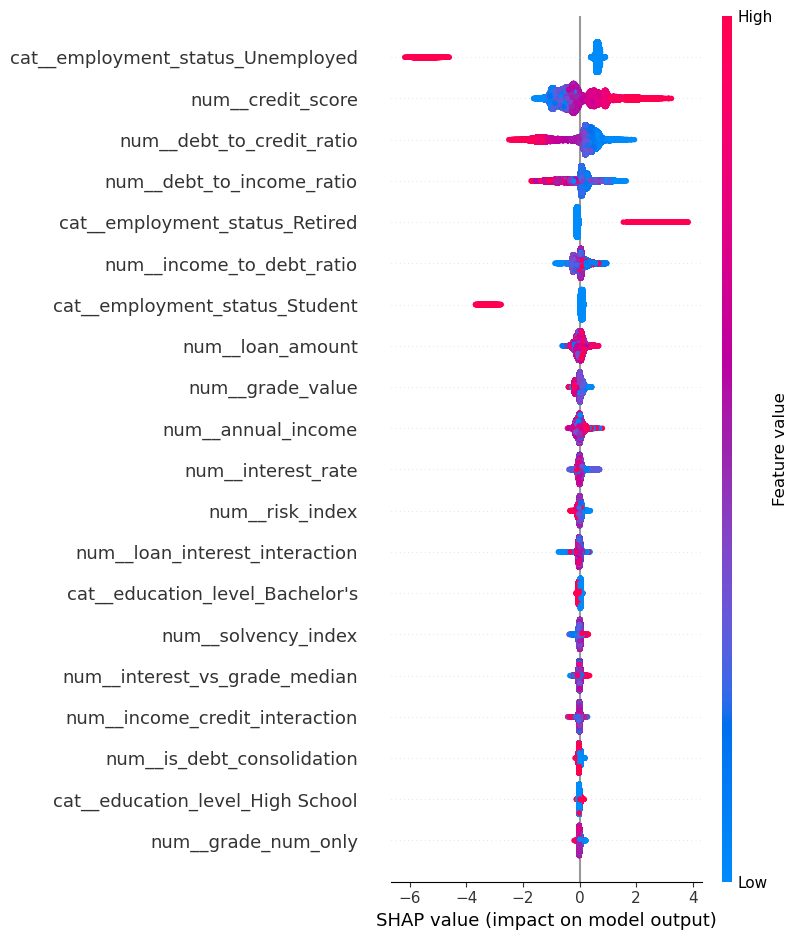

In [45]:
shap.summary_plot(shap_values, X_val_transformed, feature_names=feature_names)

## SHAP Feature Importance Analysis

The SHAP summary plot shows the impact of each feature on the LightGBM model's predictions:

- **Most influential features:**
  - `cat__employment_status_Unemployed` and `cat__employment_status_Retired` have strong effects, significantly decreasing the probability of loan repayment when active.  
  - `num__credit_score` positively impacts repayment: higher credit scores increase the predicted probability.  
  - `num__debt_to_income_ratio` and `num__debt_to_credit_ratio` strongly decrease repayment probability when high.  

- **Moderate impact features:**
  - `num__annual_income`, `num__loan_amount`, `num__interest_rate`, and `num__grade_value` contribute moderately to predictions.  
  - Interaction features (e.g., `num__loan_interest_interaction`, `num__income_credit_interaction`) show smaller but noticeable effects.  

- **Low impact features:**
  - Many categorical variables (e.g., `cat__education_level_High School`, `cat__employment_status_Student`) and less significant numerical features (`num__solvency_index`, `num__grade_num_only`) have minimal impact individually.  


**Conclusion:** The SHAP analysis confirms that **employment status, debt ratios, and credit score** are the dominant drivers of the model's predictions, consistent with correlation and statistical significance analysis.

In [46]:
import joblib 

try:
    joblib.dump(pipe_lgb, 'output/lgb_pipeline.pkl')
    print('Pipeline saved successfully.')
except Exception as e:
    print(f'Error saving pipeline: {e}')

Pipeline saved successfully.
